---

# Regression Trees

## Overview

Apply regression trees to the Wine dataset to predict alcohol content. This notebook uses the core decision tree concept from the relevant notebook before also illustrating how this concept can be applied to regression. 

---

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import (
    confusion_matrix, classification_report,
    mean_squared_error, r2_score
)

sns.set_theme()
plt.rcParams["figure.figsize"] = (10, 8)

---

## 2. Load the Wine Dataset

We use `sklearn.datasets.load_wine()` to access the data.

The dataset contains:
- **178 samples** of wine
- **13 numeric chemistry features** (alcohol, malic acid, ash, flavanoids, proline, etc.)
- **3 cultivar classes** (class_0, class_1, class_2)

---

In [2]:
data = load_wine()

X_df = pd.DataFrame(data.data, columns=data.feature_names)
y_s  = pd.Series(data.target, name="cultivar")

target_names  = list(data.target_names)
class_mapping = {i: name for i, name in enumerate(target_names)}

print("Feature matrix shape:", X_df.shape)
print("Target shape        :", y_s.shape)
print("\nClasses:", target_names)
print("\nClass distribution:")
print(y_s.value_counts().rename(index=class_mapping))

X_df.head()

Feature matrix shape: (178, 13)
Target shape        : (178,)

Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Class distribution:
cultivar
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
X_df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


---

## 3. Exploratory Data Analysis

Before building any model, we look at class distribution and feature correlations to understand the structure of the data.

---

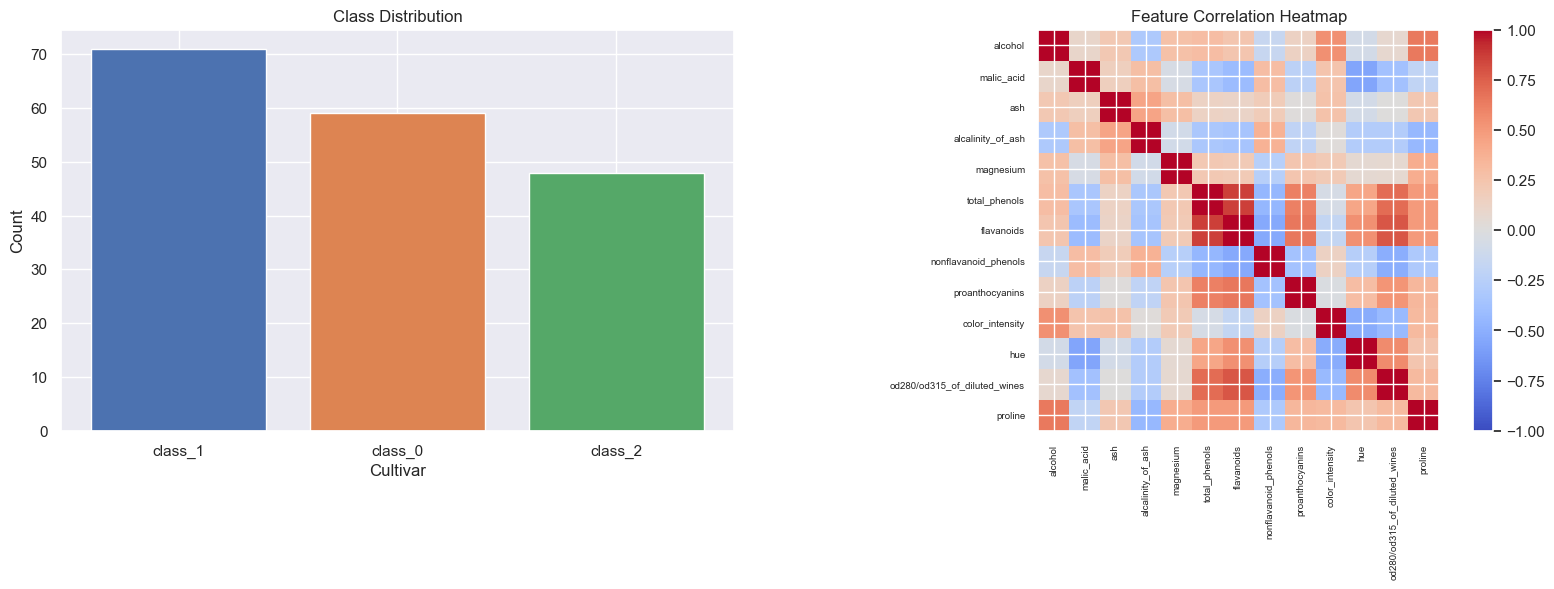

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Class distribution
counts = y_s.map(class_mapping).value_counts()
axes[0].bar(counts.index, counts.values, color=["C0", "C1", "C2"])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Cultivar")
axes[0].set_ylabel("Count")

# Correlation heatmap
corr = X_df.corr()
im   = axes[1].imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr.columns)))
axes[1].set_yticks(range(len(corr.columns)))
axes[1].set_xticklabels(corr.columns, rotation=90, fontsize=7)
axes[1].set_yticklabels(corr.columns, fontsize=7)
axes[1].set_title("Feature Correlation Heatmap")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

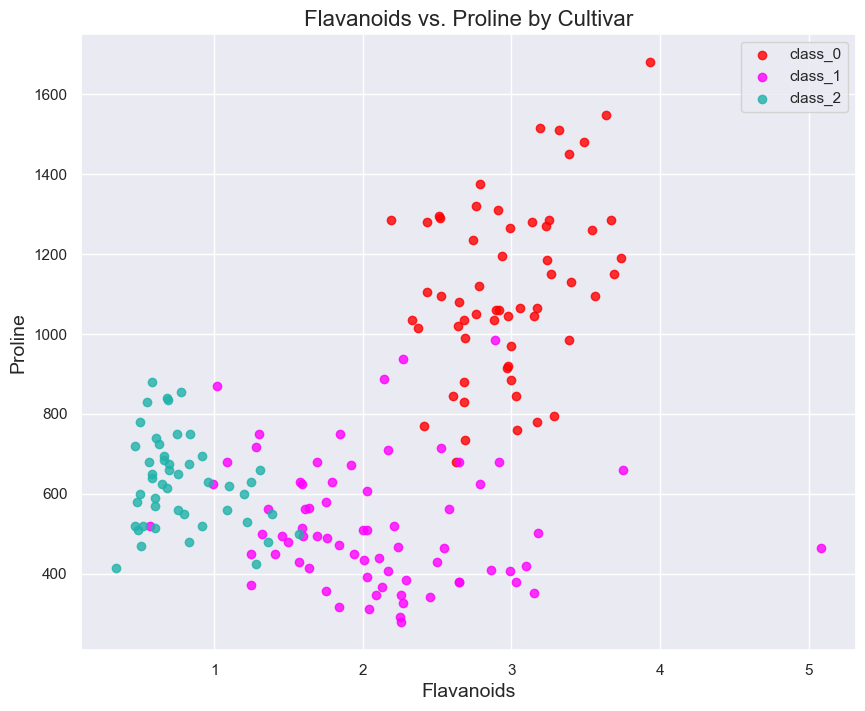

In [5]:
# Scatter plot: two highly discriminating features
colors = ["red", "magenta", "lightseagreen"]

fig, ax = plt.subplots(figsize=(10, 8))
for cls, color in zip(range(3), colors):
    mask = y_s == cls
    ax.scatter(X_df.loc[mask, "flavanoids"],
               X_df.loc[mask, "proline"],
               c=color, label=class_mapping[cls], alpha=0.8)

ax.set_xlabel("Flavanoids", fontsize=14)
ax.set_ylabel("Proline", fontsize=14)
ax.set_title("Flavanoids vs. Proline by Cultivar", fontsize=16)
ax.legend()
plt.show()

---

## 4. Decision Tree Classifier

### Part A: Train / Test Split

We set aside 40% of the data for testing, using a stratified split so every class is equally represented in both sets.

---

In [6]:
X = X_df.to_numpy()
y = y_s.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set    :", X_test.shape,  y_test.shape)

Training set: (106, 13) (106,)
Test set    : (72, 13) (72,)


---

### Part B: Fit a Decision Tree Classifier

We instantiate a `DecisionTreeClassifier` with `max_depth=3` — shallow enough to visualize, deep enough to be useful.

**Decision trees split the feature space using thresholds on individual features**, choosing at each node the split that minimizes impurity (Gini by default).

---

In [7]:
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

print("Tree fitted successfully.")
print(f"Number of leaves : {clf.get_n_leaves()}")
print(f"Tree depth       : {clf.get_depth()}")

Tree fitted successfully.
Number of leaves : 5
Tree depth       : 3


---

### Part C: Visualize the Tree Structure

The text representation shows the exact decision rules at every node.

---

In [8]:
tree_rules = export_text(clf, feature_names=list(data.feature_names))
print(tree_rules)

|--- color_intensity <= 3.46
|   |--- class: 1
|--- color_intensity >  3.46
|   |--- flavanoids <= 2.10
|   |   |--- hue <= 0.97
|   |   |   |--- class: 2
|   |   |--- hue >  0.97
|   |   |   |--- class: 1
|   |--- flavanoids >  2.10
|   |   |--- alcohol <= 12.74
|   |   |   |--- class: 1
|   |   |--- alcohol >  12.74
|   |   |   |--- class: 0



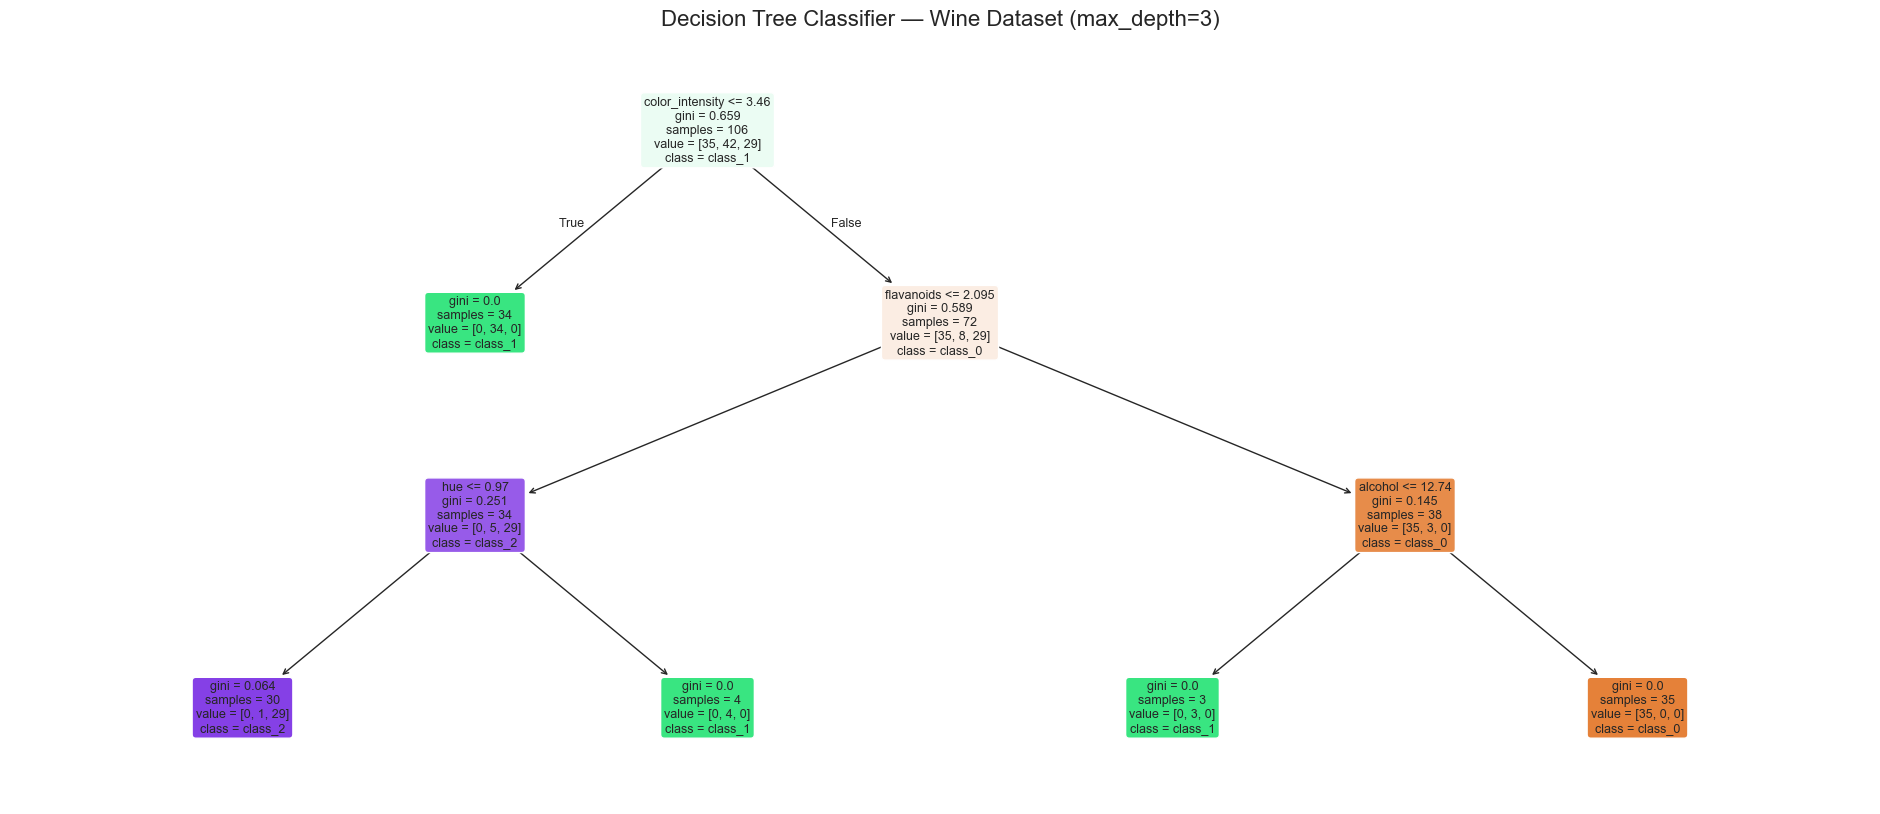

In [9]:
plt.figure(figsize=(24, 10))
plot_tree(
    clf,
    feature_names=list(data.feature_names),
    class_names=target_names,
    rounded=True,
    filled=True,
    fontsize=9
)
plt.title("Decision Tree Classifier — Wine Dataset (max_depth=3)", fontsize=16)
plt.show()

---

### Part D: 2D Decision Region (Flavanoids vs. Proline)

Because our data is 13-dimensional we project onto the two most discriminating features to visualize the decision boundaries.

---

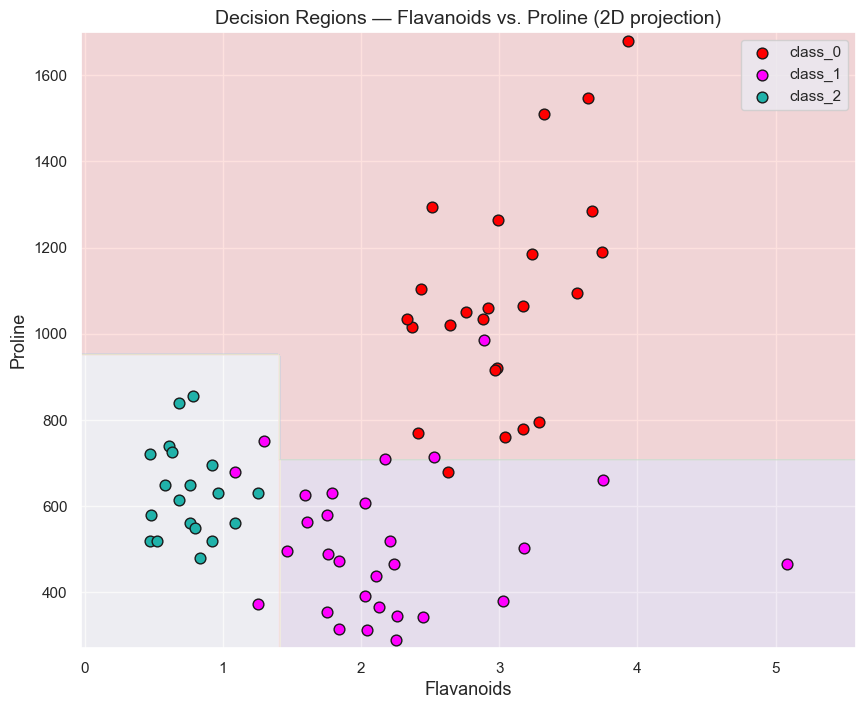

In [10]:
# Feature indices for the 2-D projection
feat_idx = {
    "flavanoids": list(data.feature_names).index("flavanoids"),
    "proline"   : list(data.feature_names).index("proline"),
}

X2_train = X_train[:, [feat_idx["flavanoids"], feat_idx["proline"]]]
X2_test  = X_test [:, [feat_idx["flavanoids"], feat_idx["proline"]]]

clf2d = DecisionTreeClassifier(max_depth=3, random_state=42)
clf2d.fit(X2_train, y_train)

# Build a mesh grid
x_min, x_max = X2_test[:, 0].min() - 0.5, X2_test[:, 0].max() + 0.5
y_min, y_max = X2_test[:, 1].min() - 20,  X2_test[:, 1].max() + 20
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = clf2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_light = plt.cm.get_cmap("Pastel1")
cmap_dark  = ["red", "magenta", "lightseagreen"]

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)
for cls, color in zip(range(3), cmap_dark):
    mask = y_test == cls
    ax.scatter(X2_test[mask, 0], X2_test[mask, 1],
               c=color, label=class_mapping[cls], edgecolors="k", s=60)

ax.set_xlabel("Flavanoids", fontsize=13)
ax.set_ylabel("Proline", fontsize=13)
ax.set_title("Decision Regions — Flavanoids vs. Proline (2D projection)", fontsize=14)
ax.legend()
plt.show()

---

### Part E: Evaluate the Classifier

---

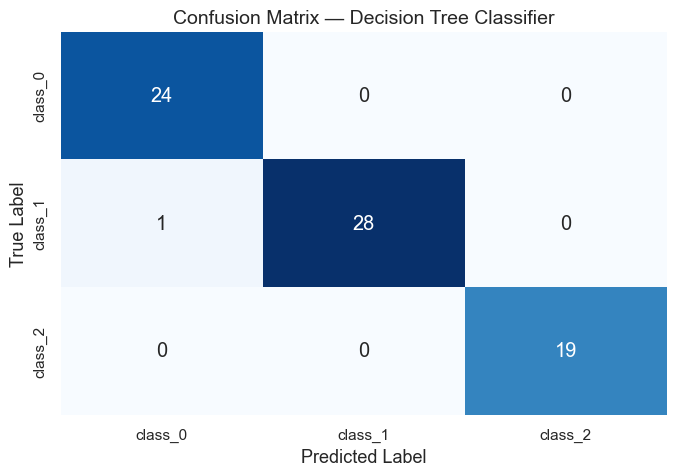

In [11]:
y_pred_clf = clf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_clf)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

fig, ax = plt.subplots(figsize=(7, 5))
sns.set(font_scale=1.2)
sns.heatmap(cm_df, annot=True, fmt="g", ax=ax, cmap="Blues", cbar=False)
ax.set_title("Confusion Matrix — Decision Tree Classifier", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
print(classification_report(y_test, y_pred_clf, target_names=target_names))

              precision    recall  f1-score   support

     class_0       0.96      1.00      0.98        24
     class_1       1.00      0.97      0.98        29
     class_2       1.00      1.00      1.00        19

    accuracy                           0.99        72
   macro avg       0.99      0.99      0.99        72
weighted avg       0.99      0.99      0.99        72



---

## 5. Regression Tree — Predicting Alcohol Content

 Instead of predicting a class label, a regression tree predicts a continuous value — here, the **alcohol content** of a wine sample from the remaining 12 chemical features.

The tree minimizes **Mean Squared Error (MSE)** at each split rather than Gini impurity.

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

---

### Part A: Prepare Regression Data

We predict **alcohol** (feature index 0) from the remaining 12 features.

---

In [13]:
alcohol_idx = list(data.feature_names).index("alcohol")
other_features = [f for f in data.feature_names if f != "alcohol"]

X_reg = X_df[other_features].to_numpy()
y_reg = X_df["alcohol"].to_numpy()

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.40, random_state=42
)

print("Regression target  : alcohol")
print("Regression features:", other_features)
print("\nTraining set:", X_reg_train.shape)
print("Test set    :", X_reg_test.shape)
print(f"\nTarget range: [{y_reg.min():.2f}, {y_reg.max():.2f}]")
print(f"Target mean : {y_reg.mean():.2f}")

Regression target  : alcohol
Regression features: ['malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Training set: (106, 12)
Test set    : (72, 12)

Target range: [11.03, 14.83]
Target mean : 13.00


---

### Part B: Shallow vs. Deep Regression Trees

First we directly compare a very shallow tree (`max_depth=1`) with a very deep one (`max_depth=20`) to illustrate underfitting vs. overfitting.

---

In [14]:
reg_shallow = DecisionTreeRegressor(max_depth=1, random_state=42)
reg_shallow.fit(X_reg_train, y_reg_train)
y_pred_shallow = reg_shallow.predict(X_reg_test)

mse_shallow = mean_squared_error(y_reg_test, y_pred_shallow)
r2_shallow  = r2_score(y_reg_test, y_pred_shallow)

print(f"Shallow tree (max_depth=1)")
print(f"  MSE : {mse_shallow:.4f}")
print(f"  R²  : {r2_shallow:.4f}")
print()

reg_deep = DecisionTreeRegressor(max_depth=20, random_state=42)
reg_deep.fit(X_reg_train, y_reg_train)
y_pred_deep = reg_deep.predict(X_reg_test)

mse_deep = mean_squared_error(y_reg_test, y_pred_deep)
r2_deep  = r2_score(y_reg_test, y_pred_deep)

print(f"Deep tree   (max_depth=20)")
print(f"  MSE : {mse_deep:.4f}")
print(f"  R²  : {r2_deep:.4f}")

Shallow tree (max_depth=1)
  MSE : 0.3793
  R²  : 0.2861

Deep tree   (max_depth=20)
  MSE : 0.4054
  R²  : 0.2371


---

### Part C: Visualize the Shallow Regression Tree

---

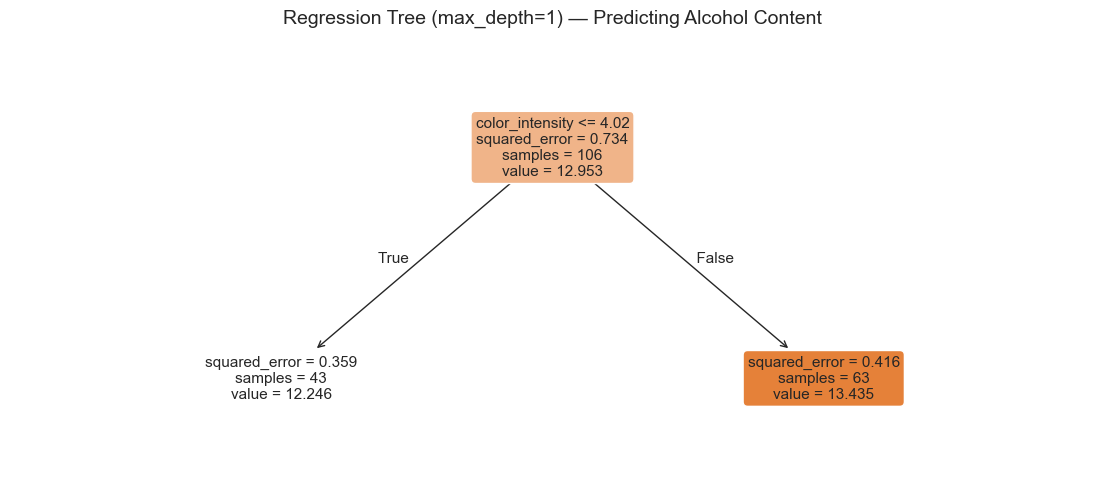

In [15]:
plt.figure(figsize=(14, 6))
plot_tree(
    reg_shallow,
    feature_names=other_features,
    rounded=True,
    filled=True,
    fontsize=11
)
plt.title("Regression Tree (max_depth=1) — Predicting Alcohol Content", fontsize=14)
plt.show()

---

### Part D: Predicted vs. Actual Alcohol Content

A scatter plot of predicted vs. actual values. A perfect model would lie on the diagonal $y = \hat{y}$.

---

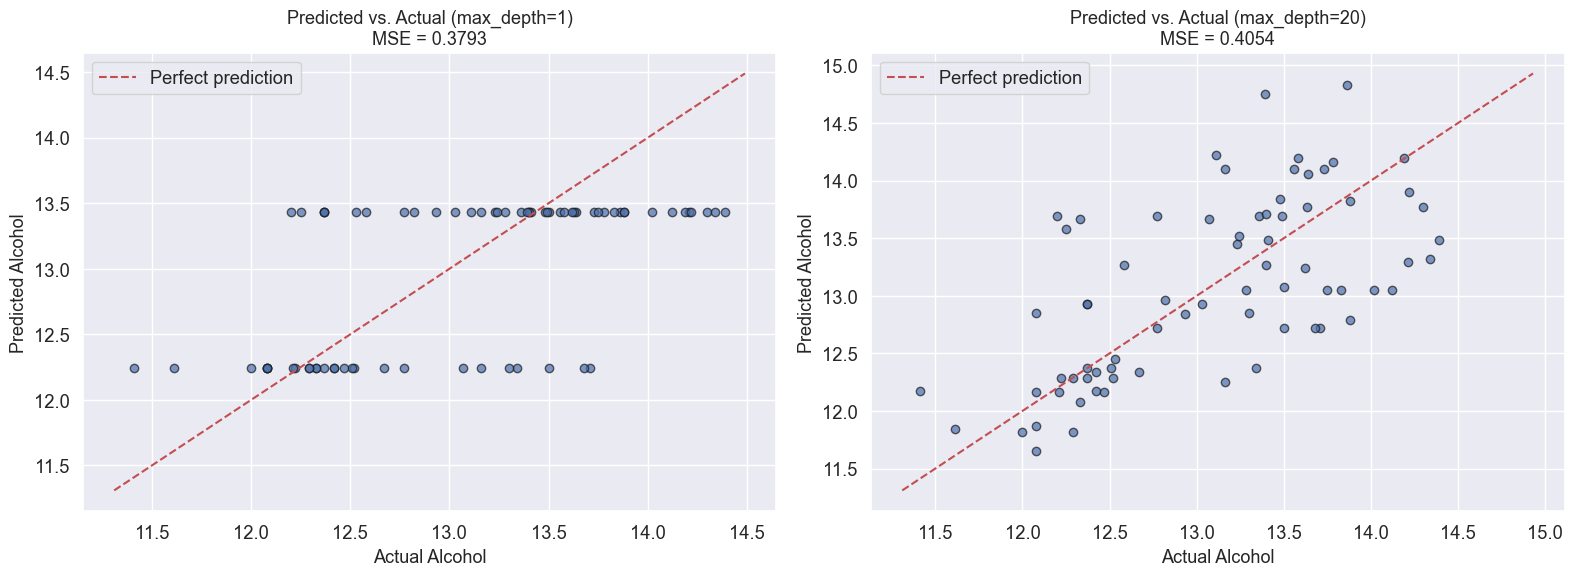

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, label, mse in [
    (axes[0], y_pred_shallow, "max_depth=1",  mse_shallow),
    (axes[1], y_pred_deep,   "max_depth=20", mse_deep),
]:
    ax.scatter(y_reg_test, y_pred, alpha=0.7, edgecolors="k")
    lo = min(y_reg_test.min(), y_pred.min()) - 0.1
    hi = max(y_reg_test.max(), y_pred.max()) + 0.1
    ax.plot([lo, hi], [lo, hi], "r--", label="Perfect prediction")
    ax.set_xlabel("Actual Alcohol", fontsize=13)
    ax.set_ylabel("Predicted Alcohol", fontsize=13)
    ax.set_title(f"Predicted vs. Actual ({label})\nMSE = {mse:.4f}", fontsize=13)
    ax.legend()

plt.tight_layout()
plt.show()

---

## 6. Tuning `max_depth`, the Bias–Variance Trade-off

Neither a depth-1 nor a depth-20 tree is necessarily optimal. We sweep over depths 1–15 and record **both training and test MSE** to identify the sweet spot.

- **Low depth** → high bias (underfitting)
- **High depth** → high variance (overfitting)

---

In [17]:
depths      = list(range(1, 16))
train_mses  = []
test_mses   = []

for d in depths:
    reg = DecisionTreeRegressor(max_depth=d, random_state=42)
    reg.fit(X_reg_train, y_reg_train)
    train_mses.append(mean_squared_error(y_reg_train, reg.predict(X_reg_train)))
    test_mses.append( mean_squared_error(y_reg_test,  reg.predict(X_reg_test)))

print(f"{'Depth':>6} | {'Train MSE':>10} | {'Test MSE':>10}")
print("-" * 32)
for d, tr, te in zip(depths, train_mses, test_mses):
    print(f"{d:>6} | {tr:>10.4f} | {te:>10.4f}")

 Depth |  Train MSE |   Test MSE
--------------------------------
     1 |     0.3928 |     0.3793
     2 |     0.2717 |     0.2500
     3 |     0.1816 |     0.2822
     4 |     0.1147 |     0.3772
     5 |     0.0715 |     0.4408
     6 |     0.0452 |     0.4204
     7 |     0.0274 |     0.4164
     8 |     0.0118 |     0.4230
     9 |     0.0046 |     0.4146
    10 |     0.0005 |     0.3994
    11 |     0.0000 |     0.3877
    12 |     0.0000 |     0.4054
    13 |     0.0000 |     0.4054
    14 |     0.0000 |     0.4054
    15 |     0.0000 |     0.4054


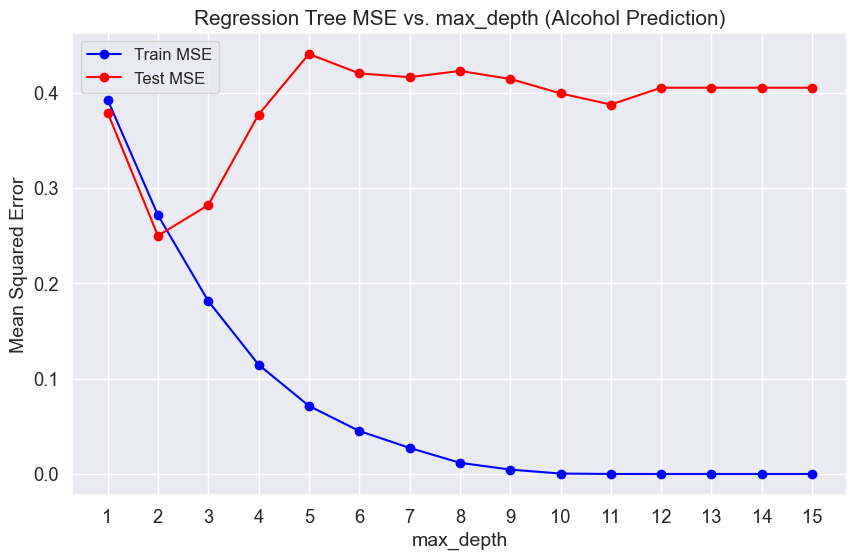

Best max_depth = 2  (test MSE = 0.2500)


In [18]:
plt.figure(figsize=(10, 6))
plt.plot(depths, train_mses, marker="o", label="Train MSE", color="blue")
plt.plot(depths, test_mses,  marker="o", label="Test MSE",  color="red")
plt.xlabel("max_depth", fontsize=14)
plt.ylabel("Mean Squared Error", fontsize=14)
plt.title("Regression Tree MSE vs. max_depth (Alcohol Prediction)", fontsize=15)
plt.xticks(depths)
plt.legend(fontsize=12)
plt.show()

best_depth = depths[test_mses.index(min(test_mses))]
print(f"Best max_depth = {best_depth}  (test MSE = {min(test_mses):.4f})")

---

## 7. Best Regression Tree

We retrain using the best depth found above and take a final look at its structure and performance.

---

In [19]:
best_reg = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
best_reg.fit(X_reg_train, y_reg_train)
y_pred_best = best_reg.predict(X_reg_test)

mse_best = mean_squared_error(y_reg_test, y_pred_best)
r2_best  = r2_score(y_reg_test, y_pred_best)

print(f"Best Regression Tree  (max_depth={best_depth})")
print(f"  MSE : {mse_best:.4f}")
print(f"  RMSE: {np.sqrt(mse_best):.4f}")
print(f"  R²  : {r2_best:.4f}")

Best Regression Tree  (max_depth=2)
  MSE : 0.2500
  RMSE: 0.5000
  R²  : 0.5295


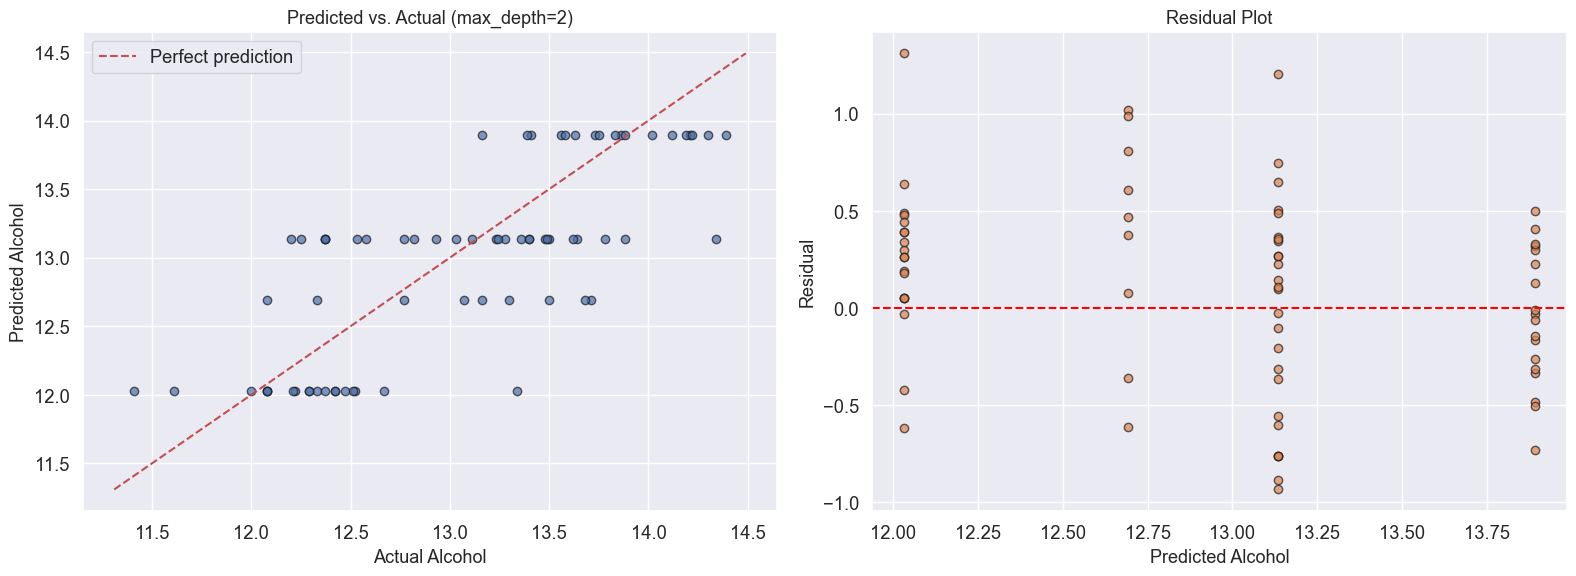

In [20]:
# Residual plot
residuals = y_reg_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predicted vs. actual
axes[0].scatter(y_reg_test, y_pred_best, alpha=0.7, edgecolors="k")
lo = min(y_reg_test.min(), y_pred_best.min()) - 0.1
hi = max(y_reg_test.max(), y_pred_best.max()) + 0.1
axes[0].plot([lo, hi], [lo, hi], "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual Alcohol", fontsize=13)
axes[0].set_ylabel("Predicted Alcohol", fontsize=13)
axes[0].set_title(f"Predicted vs. Actual (max_depth={best_depth})", fontsize=13)
axes[0].legend()

# Residuals
axes[1].scatter(y_pred_best, residuals, alpha=0.7, edgecolors="k", color="C1")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted Alcohol", fontsize=13)
axes[1].set_ylabel("Residual", fontsize=13)
axes[1].set_title("Residual Plot", fontsize=13)

plt.tight_layout()
plt.show()

---

## 8. Feature Importance

One of the great advantages of tree-based models is built-in **feature importance** — how much each feature reduced MSE (or Gini) across all splits.

---

In [21]:
importances = best_reg.feature_importances_
imp_df = pd.DataFrame({"feature": other_features, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).reset_index(drop=True)

print(imp_df.to_string(index=False))

                     feature  importance
             color_intensity    0.822587
                     proline    0.177413
                  malic_acid    0.000000
                         ash    0.000000
           alcalinity_of_ash    0.000000
                   magnesium    0.000000
               total_phenols    0.000000
                  flavanoids    0.000000
        nonflavanoid_phenols    0.000000
             proanthocyanins    0.000000
                         hue    0.000000
od280/od315_of_diluted_wines    0.000000


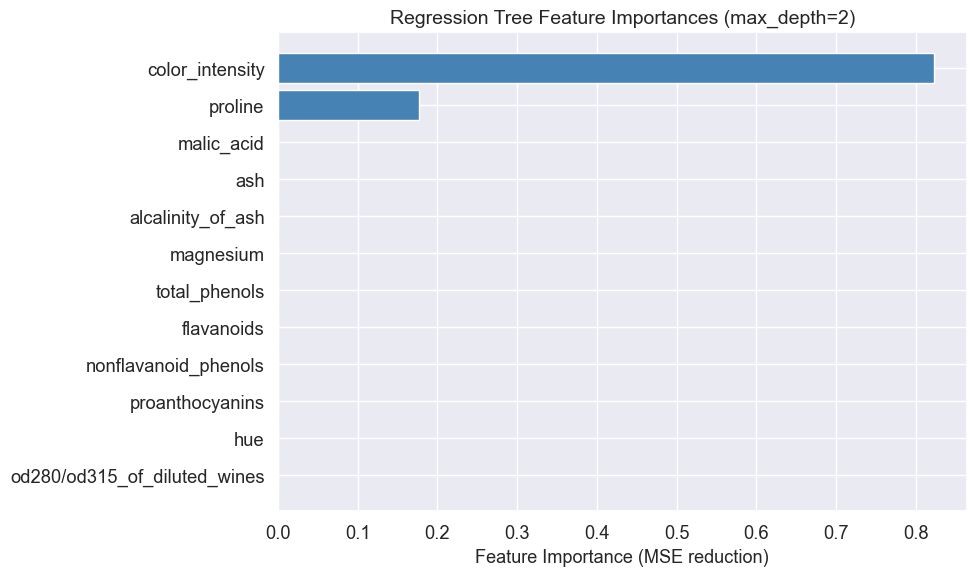

In [22]:
plt.figure(figsize=(10, 6))
plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="steelblue")
plt.xlabel("Feature Importance (MSE reduction)", fontsize=13)
plt.title(f"Regression Tree Feature Importances (max_depth={best_depth})", fontsize=14)
plt.tight_layout()
plt.show()